In [3]:
import sys
print(sys.executable)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print('numpy: ',np.__version__)
print('pandas: ',pd.__version__)
print(' matplotlib :',matplotlib.__version__)
print('seaborn: ',  sns.__version__)
print('sqlite3: ',  sqlite3.sqlite_version)

c:\Users\vr616\python\Customer-Churn-Analysis\.venv\Scripts\python.exe
numpy:  2.5.3
pandas:  3.0.5
 matplotlib : 3.11.1
seaborn:  0.13.2
sqlite3:  3.45.3


In [4]:
# IMPORTING DATABASE!
conn = sqlite3.connect('../data/customer_churn.db')
sql_query = """
        SELECT name FROM sqlite_master WHERE type='table';        
"""
# above query meaning:- From SQLite's database-information table(sqlite_master), give me the names of all objects whose type is table.

tables = pd.read_sql_query(sql_query,conn)
print(tables)



# create dataframe of each table!  # using global method
# for table_name in tables['name']:
#         df = pd.read_sql_query(f'SELECT * FROM {table_name}',conn)
#         globals()[f'df_{table_name}'] = df     # WITHOUT globals()[]   f'df_{table_name}' = df would be like 'df_db_customer' = df means storing dataframe in a string!?? wrong!! so we make that thing a variable using globals!! 
#         print(f'Created dataframe: df_{table_name}')

# USING DICTIONARY TO STORE EACH TABLES AS DICTIONARY ITEMS

dataframes = {}

for table_name in tables['name']:
        dataframes[table_name] = pd.read_sql_query(f'SELECT * FROM {table_name}',conn)
        print(f'table {table_name} stored in dataframes')

   

conn.close()

              name
0      db_customer
1  db_subscription
2       db_support
table db_customer stored in dataframes
table db_subscription stored in dataframes
table db_support stored in dataframes


In [5]:
dataframes['db_customer'].head()
dataframes['db_subscription'].head()
dataframes['db_support'].head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [6]:
for name,df in dataframes.items():
    print(f'shape of {name} dataframe is {df.shape} ')

shape of db_customer dataframe is (21, 8) 
shape of db_subscription dataframe is (21, 11) 
shape of db_support dataframe is (9, 6) 


# DATA CLEANING
### Data cleaning is the process of finding and fixing errors, missing values, duplicates, incorrect data types, and inconsistent data in a dataset.

Example:
Convert inconsistent gender values:

df['gender'] = df['gender'].replace({'Men': 'Male', 'Women': 'Female'})

Messy data → clean, consistent, reliable data → ready for analysis/ML.

In [7]:
# 1: db_customer table cleaning

dataframes['db_customer'].head()
dataframes['db_customer']['country']
dataframes['db_customer']['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [8]:
dataframes['db_customer'].duplicated().sum()

np.int64(0)

In [9]:
dataframes['db_customer'].info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [10]:
# STEPS TO DO TO CLEAN DB_CUSTOMER TABLE:
# 1: DROP INTERESTS AND PINCODE COLUMNS AS THEY GOT MANY NULL VALUES AND ARE USELESS
# 2: CHANGE DTYPE OF dob COLUMN TO DATETIME FORMAT
# 3: FIX THE NULL VALUES IN COUNTRY COLUMN
# 4: NORMALIZE GENDER COLUMN TO MALE AND FEMALE ONLY (IT CONTAINS MALE,FEMALE,WOMEN,MEN RIGHT NOW)
# 5: also check for duplicates values if any : checked no duplicates found!

In [11]:
# 1:
dataframes['db_customer'].drop(['interests','pincode'],axis=1,inplace=True)

# 1 done


In [12]:
# 2:
dataframes['db_customer']['dob'] = pd.to_datetime(dataframes['db_customer']['dob'])

# 2 done

In [13]:
dataframes['db_customer'].info()
dataframes['db_customer'].head()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   customerid  21 non-null     str           
 1   name        21 non-null     str           
 2   country     18 non-null     str           
 3   state       21 non-null     str           
 4   gender      21 non-null     str           
 5   dob         21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05


In [14]:
# 3:
dataframes['db_customer'][['country','state']] 

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,NaN,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,NaN,Kathmandu
9,Nepal,Kathmandu


In [15]:
dataframes['db_customer'][dataframes['db_customer']['country'].isna()]

,customerid,name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [16]:
dataframes['db_customer'].dropna(subset=['country'])

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29
10,0017-DINOC,shiva,India,Maharashtra,Men,1997-01-22
11,0017-IUDMW,rangadevi,India,Karnataka,Female,1981-06-18


In [17]:
dataframes['db_customer'].groupby('state')['country'].unique()

state
Delhi            [India, nan]
Karnataka             [India]
Kathmandu        [nan, Nepal]
Maharashtra           [India]
Meghalaya             [India]
Nagaland              [India]
Rajasthan             [India]
Telangana        [nan, India]
Uttar Pradesh         [India]
Name: country, dtype: object

In [18]:
state_country = dataframes['db_customer'].dropna(subset=['country']).set_index('state')['country'].to_dict()


dataframes['db_customer']['country'] = dataframes['db_customer']['country'].fillna(dataframes['db_customer']['state'].map(state_country))

In [19]:
dataframes['db_customer']
# 3: country null fix done!

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [20]:
# 4:
dataframes['db_customer']['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [21]:
dataframes['db_customer']['gender'] = dataframes['db_customer']['gender'].replace({'Men':'Male','Women':'Female'})
#4 done

In [22]:
dataframes['db_customer'].head()

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05


In [23]:
# db_customer table is Cleaned now !

In [24]:
# db_subscription CLeaning:

In [25]:
dataframes['db_subscription'].head()
# cltv means customer life time value

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [26]:
dataframes['db_subscription'].info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [27]:
# cleaning  db_subscription 
# 1: convert columns which includes dates to datetime dtype!


In [28]:
# 1:
date_col = ['subscription_start_date','renewal_date','cancellation_date']
dataframes['db_subscription'][date_col] = dataframes['db_subscription'][date_col].apply(pd.to_datetime)

In [29]:
dataframes['db_subscription']['plan_type'].unique()

<StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str

In [30]:
# cleaning db_support

In [31]:
dataframes['db_support'].head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [32]:
dataframes['db_support'].tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,NaN
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,NaN
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,NaN
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [33]:
dataframes['db_support'].info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [34]:
# cleaning db_support
# 1: drop col_1 
# 2: convert complaint_date column to datetime dtype


In [35]:
# 1
dataframes['db_support'].drop(['col_1','comment'],axis=1,inplace=True)

In [36]:
# 2
dataframes['db_support']['complaint_date'] = pd.to_datetime(dataframes['db_support']['complaint_date'])

In [37]:
dataframes['db_support']

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


# Feature Engineering 

### Feature engineering is the process of creating, transforming, or selecting useful input variables (features) from existing data to help a Machine Learning model learn better.

Example:
From price = ₹500 and quantity = 3, create a new feature:

total_spending = price * quantity   # ₹1500

Raw data → useful features → better representation for ML.

In [38]:
# FIRST I'M GIVING EACH DATAFRAME A SHORTER NAME
df_customer = dataframes['db_customer']
df_subscription = dataframes['db_subscription']
df_support = dataframes['db_support']

In [39]:
# churn rate : rate at which customers are leaving the platform

In [40]:
# as we know we have this cancellation date in db_subscription table where we know which customers left or not
# so WE WILL FIRST CREATE A COLUMN 'churn_flag' IN WHICH 1 TELLS CUSTOMER CHURNED(LEFT) AND 0 MEANS STILL THERE

In [41]:
# Creating new column 'churn_flag' using existing columns


df_subscription['churn_flag'] = np.where(df_subscription['cancellation_date'].notna(),1,0)
df_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [42]:
df_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [43]:
# NOW WE NEED A COMPLETE SINGLE DATAFRAME INCLUDING ALL 3 DATFRAMES

df_total = (df_subscription.merge(df_customer,on='customerid',how = 'left')
               .merge(df_support,on='customerid',how = 'left'))

In [44]:
df_customer.shape
df_customer['customerid'].nunique()

21

In [45]:
df_total.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,name,country,state,gender,dob,complaint_date,escalations,csat_score
18,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaT,NaN,13.99,840,27,0,vishakha,India,Rajasthan,Female,2000-09-02,NaT,NaN,NaN
19,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99,1,raghvendra,India,Telangana,Male,1983-12-30,2024-09-13,Y,10.0
20,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99,1,raghvendra,India,Telangana,Male,1983-12-30,2024-09-14,N,90.0
21,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaT,NaN,22.99,1955,7,0,rishabh,India,Uttar Pradesh,Male,1991-05-14,NaT,NaN,NaN
22,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaT,NaN,13.99,790,47,0,sudevi,India,Maharashtra,Female,1977-10-06,NaT,NaN,NaN


In [46]:
# VERY VERY IMP
df_total.shape

(23, 20)

In [47]:
df_subscription.shape
df_subscription['customerid'].nunique()

21

In [48]:
df_support['customerid'].nunique()

df_support.shape

(9, 4)

In [49]:
df_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [50]:
# SO WE GOT TO KNOW THAT IN SUPPORT DF THERE ARE DUPLICATE VALUES IN CUSTOMERID COLUMN WHICH COULD POSSIBLY CAUSE A BLUNDER IN FURTHER FEATURING ENGINEERING
# SO WE WILL TAKE CARE OF THIS FIRST


df_support[df_support['customerid'].duplicated(keep  = False)]

# so these 4 are duplicates ! 
# reason of values being duplicate could be that a customer did more than 1 complaint and all complaints are got stored so showing multiple same customerid 

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [51]:
df_support.groupby('customerid')['customerid'].transform('count').reset_index()

,index,customerid
0,0,2
1,1,2
2,2,1
3,3,1
4,4,1
5,5,1
6,6,1
7,7,2
8,8,2


In [52]:
# time to remove these duplicates
# first i will create a column complaint_count so that we will get this info too that is how many times customer complaint
# then we will remove the first duplicates keeping the latest complaints!!
'''
Goal	                                                Method
One count per group	                            .groupby(...).count()
Count on every row (same length as df)        	.groupby(...).transform('count')
'''
 
df_support['complaint_count'] = df_support.groupby('customerid')['customerid'].transform('count')



df_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [53]:
df_support = df_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last').reset_index(drop=True)

In [54]:
df_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0013-EXCHZ,2024-01-20,Y,20,1
1,0017-IUDMW,2024-04-10,Y,25,1
2,0003-MKNFE,2024-08-28,Y,10,2
3,0022-TCJCI,2024-09-14,N,90,2
4,0019-EFAEP,2024-09-27,Y,30,1
5,0013-SMEOE,2024-11-01,N,30,1
6,0013-MHZWF,2025-03-18,N,90,1


In [55]:
# now we will rerun merge part !

In [56]:
# NOW WE NEED A COMPLETE SINGLE DATAFRAME INCLUDING ALL 3 DATFRAMES

df_total = (df_subscription.merge(df_customer,on='customerid',how = 'left')
               .merge(df_support,on='customerid',how = 'left'))

In [57]:
df_total.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


# DATA ANALYSIS
### Data analysis is the process of examining, transforming, and interpreting data to find patterns, answer questions, and extract useful insights.
### It uses techniques such as filtering, aggregation, grouping, statistical analysis, and visualization to understand what the data is telling us.
### Example: Analyze customer data to find which plan has the highest average revenue and which group has the highest churn.

#### Raw data → Analyze → Find patterns → Insights → Decisions

In [58]:
# lets first make the csv file of our total df
df_total.to_csv('churn_data.csv',index=False)

In [59]:
df_total.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [60]:
# 1: CHURN RATE: percentage of customers leaving platform
churn_rate = df_total['churn_flag'].mean() * 100
print(f'Churn rate:- {round(churn_rate,2)} %')

# note:- 28.57% customers in dataset have churned.

Churn rate:- 28.57 %


In [61]:
# 2: Retention rate :- percentage of customers stayed/not left the platform
retention_rate = 100 - churn_rate
print(f'Retention Rate:- {round(retention_rate,2)} %')

# note:- 71.43% customers in dataset stayed or retained !

Retention Rate:- 71.43 %


In [62]:
df_total['churn_flag'].value_counts(normalize = True) * 100

churn_flag
0    71.428571
1    28.571429
Name: proportion, dtype: float64

In [63]:
# 3: Churn by plan type : how many customers churned from platform according to their plan types ['Standard', 'Premium', 'Basic']
churn_by_plan = df_total.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='Churn_rate_pct(%)')
churn_by_plan

# Note :- 60%,14.29%,22.22% customers who had basic,premium,standard plan_type respectively are churned in this database!

,plan_type,Churn_rate_pct(%)
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [64]:
# 4(a) : - churn by state + sum(revenue)/cltv + counts of users    ... show all these columns at once

churn_by_state = df_total.groupby(['state','country']).agg(churn_rate_pct = ('churn_flag',lambda x: round(x.mean()*100,2)) ,cltv_revenue_by_state = ('cltv','sum'),count_users = ('customerid','count')).reset_index()
churn_by_state
# Note:
# Delhi has a 25.00% churn rate, with 4 customers contributing a combined CLTV of 1765.
# Karnataka has a 100.00% churn rate, with 2 customers contributing a combined CLTV of 1420.
# Kathmandu has a 0.00% churn rate, with 2 customers contributing a combined CLTV of 575.
# Maharashtra has a 0.00% churn rate, with 3 customers contributing a combined CLTV of 3027.
# Meghalaya has a 66.67% churn rate, with 3 customers contributing a combined CLTV of 940.
# Nagaland has a 0.00% churn rate, with 1 customer contributing a combined CLTV of 1725.
# Rajasthan has a 0.00% churn rate, with 2 customers contributing a combined CLTV of 2680.
# Telangana has a 50.00% churn rate, with 2 customers contributing a combined CLTV of 1022.
# Uttar Pradesh has a 0.00% churn rate, with 2 customers contributing a combined CLTV of 4140.     

,state,country,churn_rate_pct,cltv_revenue_by_state,count_users
0,Delhi,India,25.00,1765,4
1,Karnataka,India,100.00,1420,2
2,Kathmandu,Nepal,0.00,575,2
3,Maharashtra,India,0.00,3027,3
4,Meghalaya,India,66.67,940,3
5,Nagaland,India,0.00,1725,1
6,Rajasthan,India,0.00,2680,2
7,Telangana,India,50.00,1022,2
8,Uttar Pradesh,India,0.00,4140,2


In [65]:
# 4(b) : churn by subscription type + sum(revenue) + count of users

churn_by_subscription_type = df_total.groupby('subscription_type').agg(churn_rate_pct=('churn_flag',lambda x:round(x.mean()*100,2)),cltv_by_subtype=('cltv','sum'),count_users=('customerid','count')).reset_index()
churn_by_subscription_type
# Note:-
# organic type has 0% churn rate ,with total 9 customers contributing a combined cltv of 8360
# paid type has 16.67% churn rate ,with total 6 customers contributing a combined cltv of 7410
# refferal type has 83.33% churn rate ,with total 6 customers contributing a combined cltv of 1524

,subscription_type,churn_rate_pct,cltv_by_subtype,count_users
0,Organic,0.00,8360,9
1,Paid,16.67,7410,6
2,Refferal,83.33,1524,6


In [66]:
#5 ARPU:- Avg Revenue Per User
arpu = df_total['monthly_charges'].mean().round(2)
arpu

np.float64(18.85)

In [67]:
# 6: Avg Customer Tenure: no. of days customer has used our service ... we can do this by subtracting either cancellation date or current todays date with starting_date!
today_date = pd.Timestamp.today() 
today_date


Timestamp('2026-09-25 00:41:26.150313')

In [68]:
# (df_total['subscription_start_date'] - today_date).dt.days

In [69]:
df_total['customer_tenure'] = np.where(df_total['cancellation_date'].notna(),
                           (df_total['cancellation_date'] - df_total['subscription_start_date']).dt.days,
                           (today_date - df_total['subscription_start_date']).dt.days)

df_total.head()
# so we now added customer tenure column now time to find average customer tenure

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,customer_tenure
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,2020.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1405.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2695.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0


In [70]:
#7: avg customer tenure

avg_customer_tenure = df_total['customer_tenure'].mean().round(0)
print(f'average customer tenure :- {avg_customer_tenure}')

# On average customers are associated with us for 1541 days

average customer tenure :- 1547.0


In [71]:
#8:  age of every customer 

df_total['customer_age'] = (today_date - df_total['dob']).dt.days // 365
df_total.head()


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,customer_tenure,customer_age
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,2020.0,44
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0,30
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1405.0,48
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2695.0,25
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0,36


In [72]:
#9:  Revenue at risk - revenue lost from churned users

revenue_loss = df_total.loc[df_total['churn_flag']==1,'monthly_charges'].sum()
print(f'revenue loss due to churned users(In RS thousand) :- {revenue_loss}')

# 74k approx revenue risk/lost caused by churned users

revenue loss due to churned users(In RS thousand) :- 73.94


In [73]:
#10:  Esclation Rate:- how many customers escalated their support request 

escalation_rate = (df_total.loc[df_total['escalations'].notna(),'escalations'].replace({'Y':1,'N':0}).mean() * 100).round(2)
print(f'Esclation rate:- {escalation_rate}%')

# note:- 57.14% of customers with recorded support activity had their request escalated.

Esclation rate:- 57.14%


In [74]:
#11:  Avg complaint per user
avg_complaint_per_user  = (df_total['complaint_count'].notna().mean())
avg_complaint_per_user

#note:- avg complaint per user = 0.33 

np.float64(0.3333333333333333)

In [75]:
#12: Correlation between escalation vs churn

df_corr = df_total[['escalations','churn_flag']].dropna().reset_index(drop=True)

df_corr['escalations'] = np.where(df_corr['escalations']=='Y',1,0) # encoding string to int type
df_corr

corr_value = (df_corr['escalations'].corr(df_corr['churn_flag'])).round(2)

print(f'correlation between escations and churn:- {corr_value}')

# Note:-
# Escalated customers show a moderate positive association with churn (correlation = 0.47),
# suggesting that customers who escalate support requests tend to have higher churn.
# However, this is based on only 7 customers with recorded escalation data, so the result should be interpreted cautiously.

correlation between escations and churn:- 0.47


In [76]:
# 13- creating a column using existing column - Churn Risk

conditions =[ (df_total['churn_score'] < 50) , 
              ((df_total['churn_score'] >= 50) & (df_total['churn_score'] <= 70)),
              (df_total['churn_score'] > 70)
]
choices = ['Low','Medium','High']

df_total['Churn_Risk'] = np.select(conditions,choices,default='Unknown')
df_total.tail(1)


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,customer_tenure,customer_age,Churn_Risk
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaT,NaN,13.99,790,...,Maharashtra,Female,1977-10-06,NaT,NaN,NaN,NaN,1364.0,49,Low


# VISUALIZATION USINIG MATPLOTLIB

In [77]:
df_visual = df_total.copy()

In [78]:
df_visual.head(1)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,customer_tenure,customer_age,Churn_Risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,2020.0,44,Low


In [79]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'customer_tenure', 'customer_age', 'Churn_Risk'],
      dtype='str')

In [80]:
#1: Monthly Churn Trend (Time Series KPI)
# we need to get in which month customers are getting churned! using cancellation date 

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

In [81]:
df_visual[['cancellation_month','churn_flag']]

,cancellation_month,churn_flag
0,NaT,0
1,2024-09,1
2,NaT,0
3,NaT,0
4,2024-02,1
5,NaT,0
6,2024-11,1
7,NaT,0
8,NaT,0
9,NaT,0


In [82]:
# now we need to check how many people churned month group wise
churn_trend = df_visual.groupby('cancellation_month')['churn_flag'].size().reset_index(name='no. of churned customers')

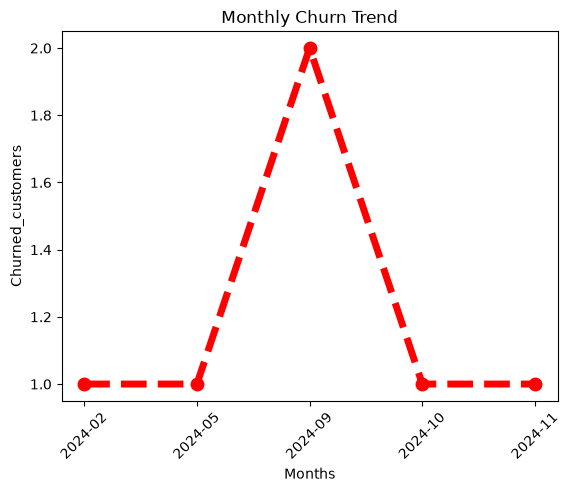

In [83]:
# now plotting time : Monthly Churn Trend
plt.plot(churn_trend['cancellation_month'].astype('str'),churn_trend['no. of churned customers'],color = 'Red',marker = 'o',linewidth=5,markersize=9,linestyle='--')
plt.xticks(rotation = 45)
plt.xlabel('Months')
plt.ylabel('Churned_customers')
plt.title('Monthly Churn Trend')
plt.show()

In [84]:
df_visual[['plan_type','churn_flag']]

,plan_type,churn_flag
0,Standard,0
1,Premium,1
2,Basic,0
3,Premium,0
4,Standard,1
5,Standard,0
6,Basic,1
7,Premium,0
8,Standard,0
9,Basic,0


In [85]:
# 2: Churn By Plan Type : means visualize how many customers exited by respective to their plan type

churn_by_plan_trend = df_visual.groupby('plan_type')['churn_flag'].mean().reset_index(name='customers_churned')
churn_by_plan_trend

,plan_type,customers_churned
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


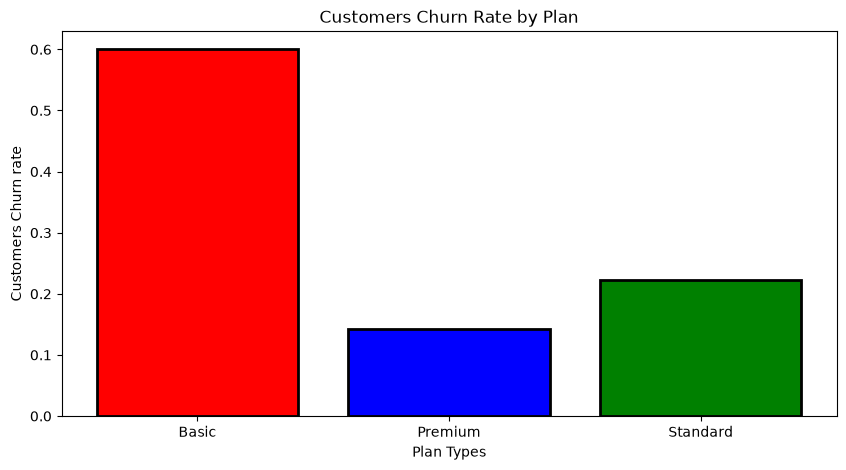

In [86]:
plt.figure(figsize=(10,5))
plt.bar(churn_by_plan_trend['plan_type'],churn_by_plan_trend['customers_churned'],color=['red','blue','green'],linewidth=2,edgecolor='black')
plt.xlabel('Plan Types')
plt.ylabel('Customers Churn rate')
plt.title('Customers Churn Rate by Plan')
plt.show()

In [87]:
# 3 churn by states
churn_by_states_trend = df_visual.groupby('state')['churn_flag'].mean().mul(100).reset_index(name='Churn_rate_pct')
churn_by_states_trend

,state,Churn_rate_pct
0,Delhi,25.000000
1,Karnataka,100.000000
2,Kathmandu,0.000000
3,Maharashtra,0.000000
4,Meghalaya,66.666667
5,Nagaland,0.000000
6,Rajasthan,0.000000
7,Telangana,50.000000
8,Uttar Pradesh,0.000000


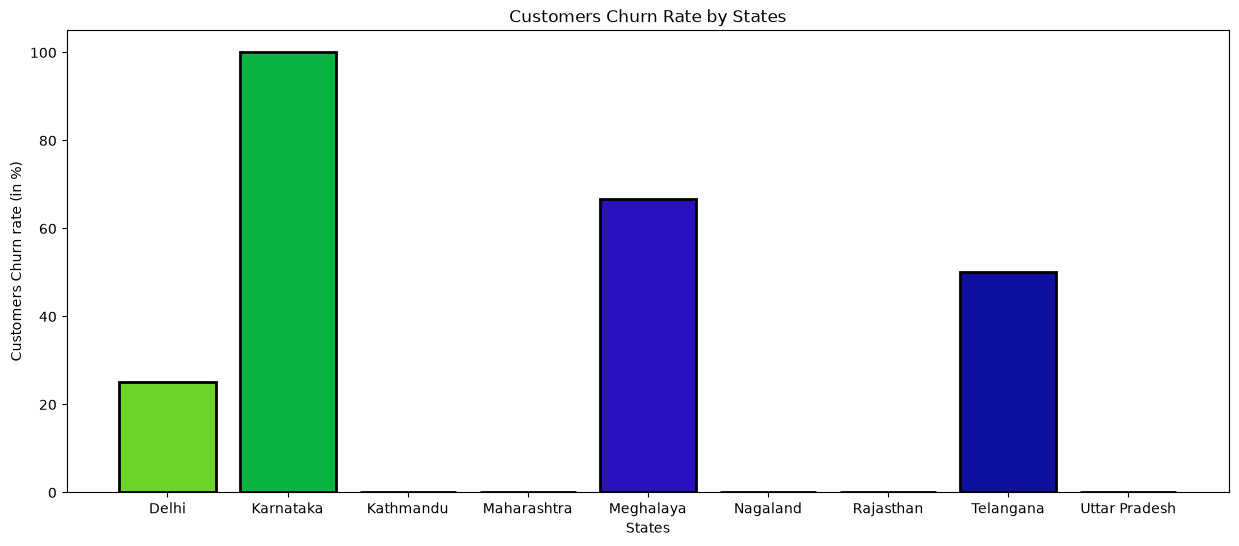

In [88]:
import random
plt.figure(figsize=(15,6))
colors = np.random.rand(len(churn_by_states_trend),3)
plt.bar(churn_by_states_trend['state'],churn_by_states_trend['Churn_rate_pct'],color=colors,linewidth=2,edgecolor='black')
plt.xlabel('States')
plt.ylabel('Customers Churn rate (in %)')
plt.title('Customers Churn Rate by States')
plt.show()

# VISUALIZATION USING SEABORN

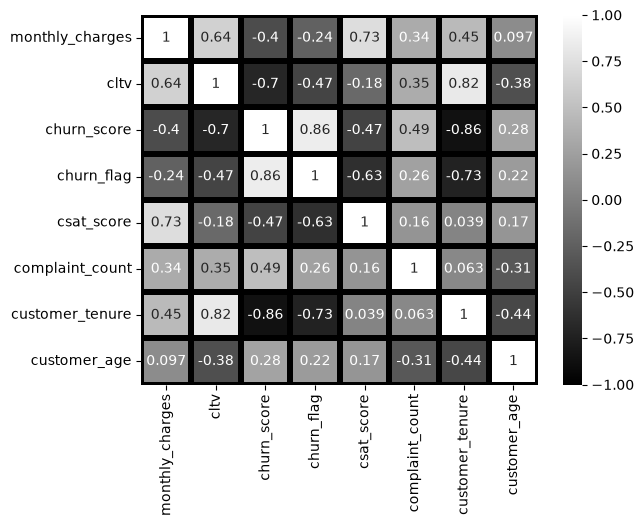

In [89]:
# HEATMAP (CORRELATION MATRIX)
# 1: checking correlation between churn_score and age of customer

correlation = df_visual.select_dtypes('number').corr()
sns.heatmap(data = correlation,annot=True,cmap='grey',vmin=-1,vmax=1,linecolor='black',linewidth=3)
plt.show()

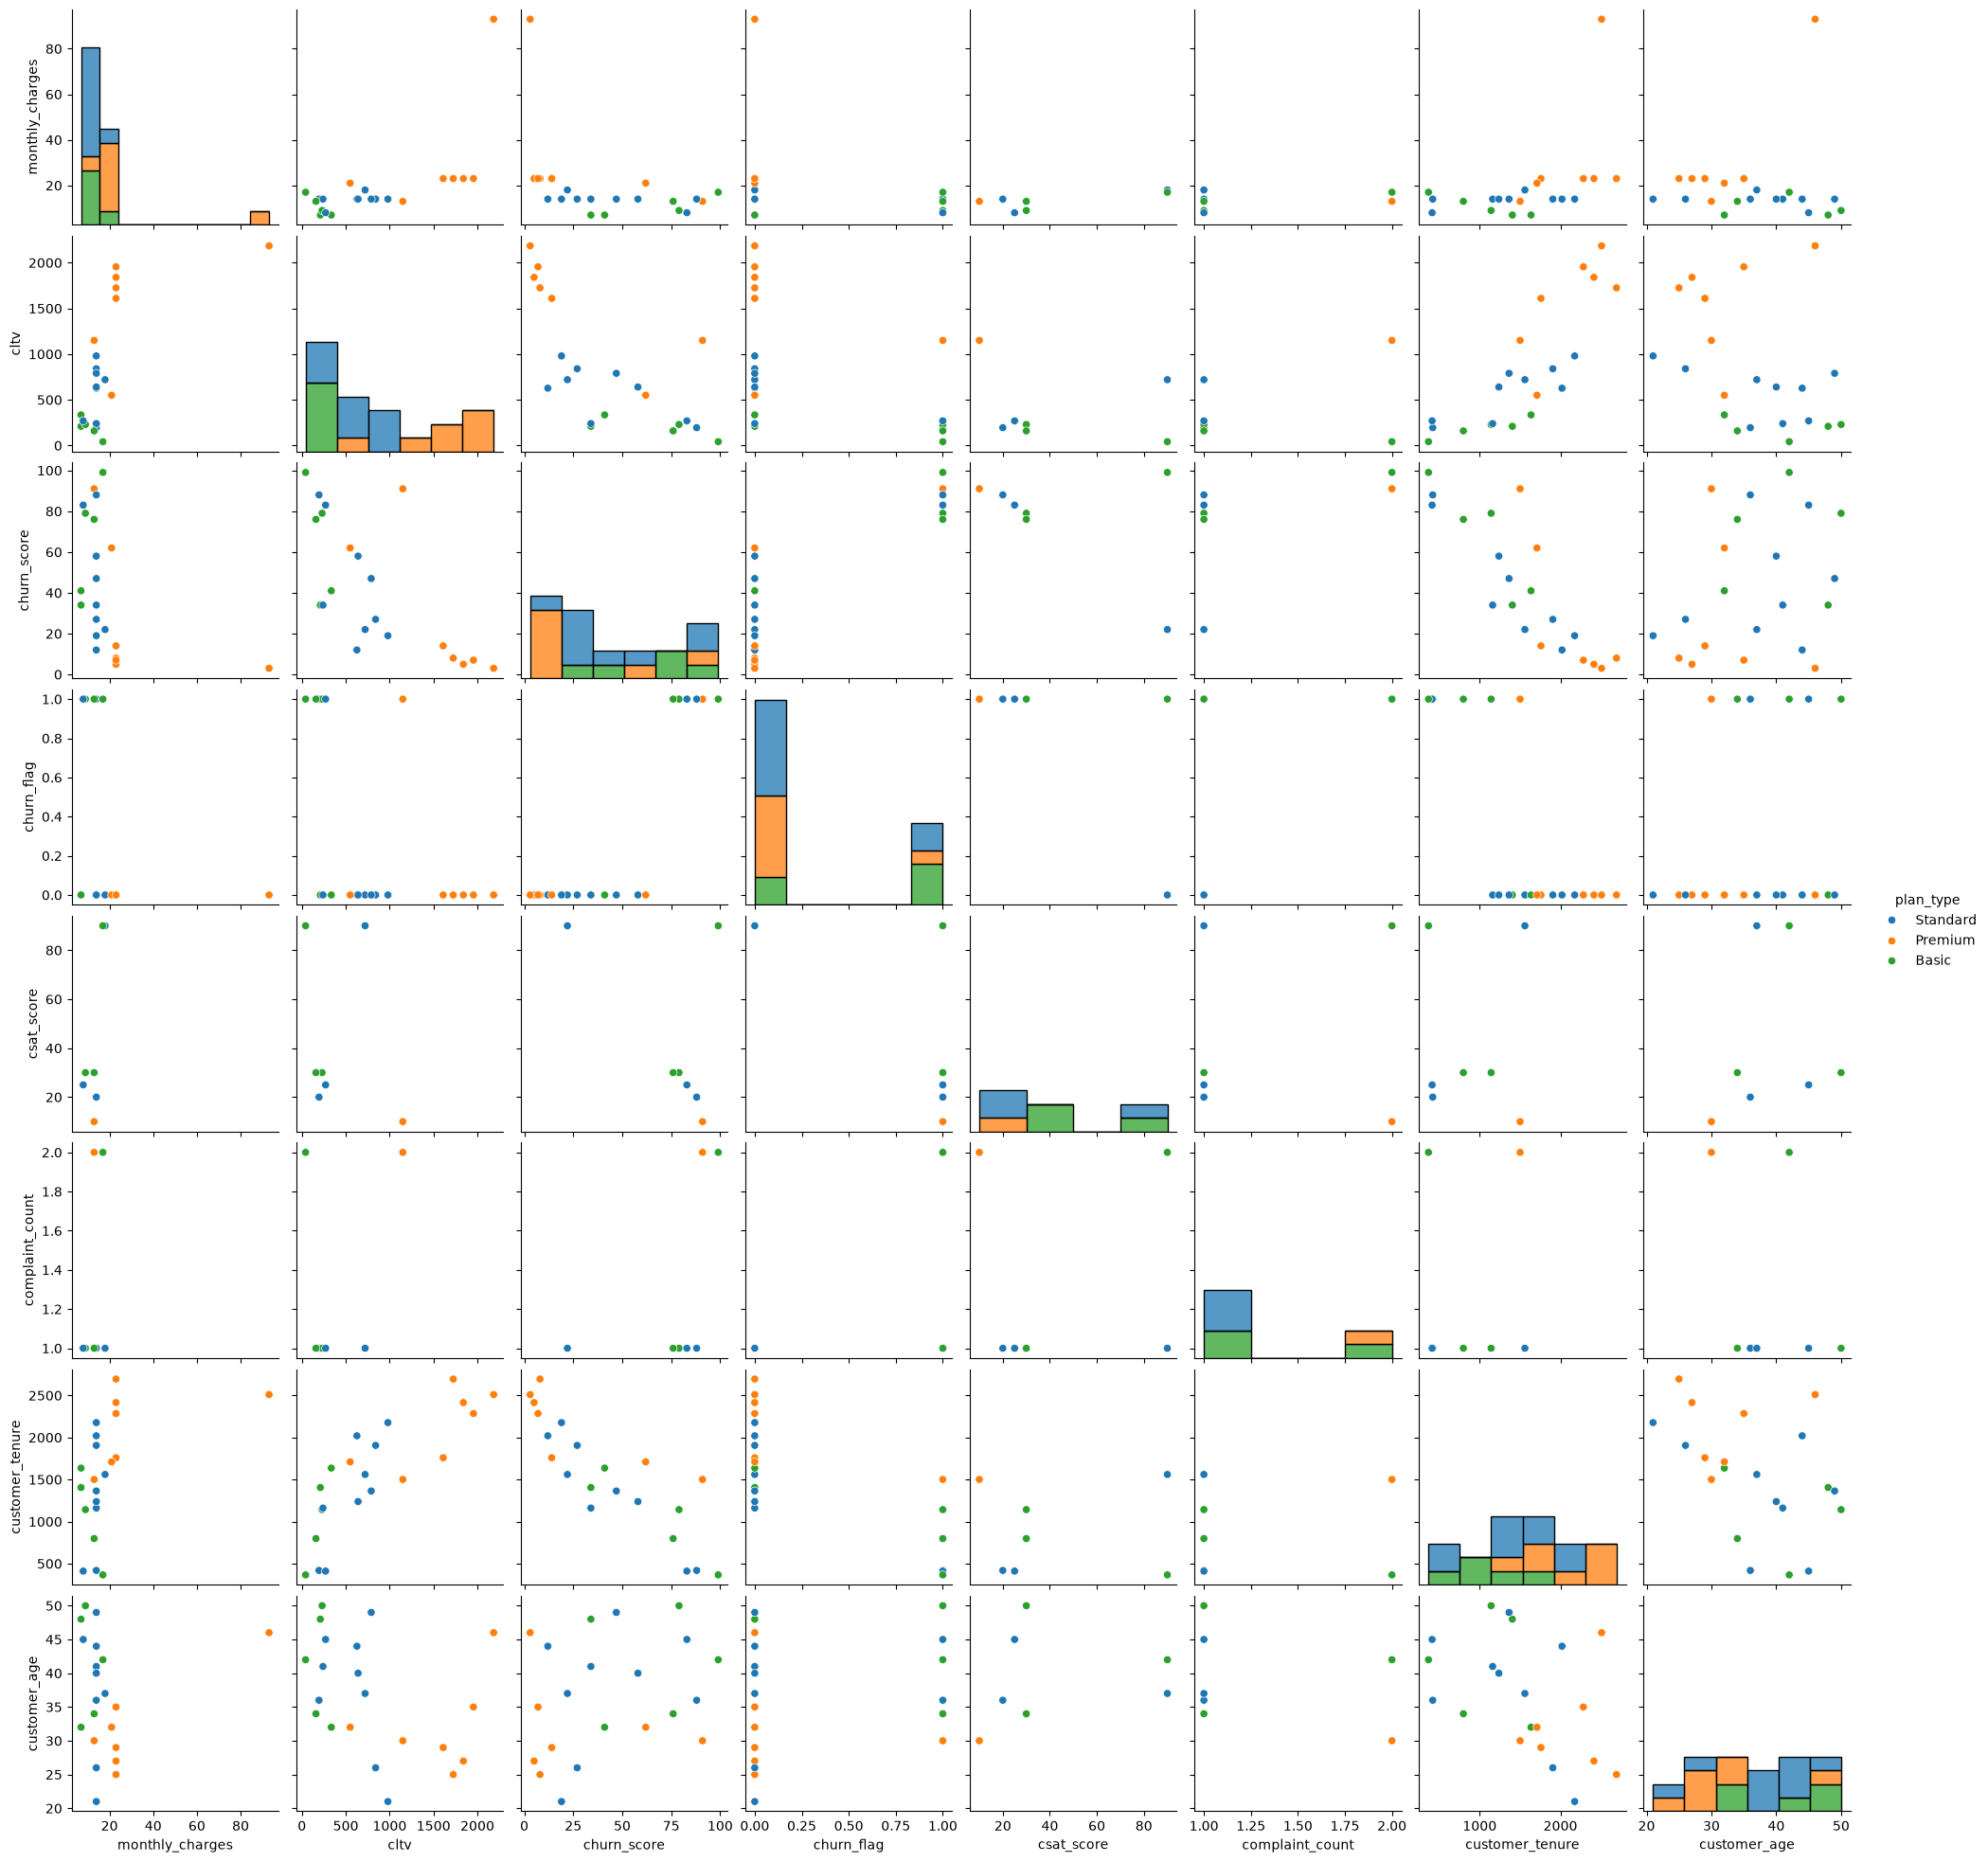

In [90]:
# Pair plot

sns.pairplot(data = df_visual,hue = 'plan_type',kind='scatter',diag_kind='hist',diag_kws={'multiple':'stack'})
plt.show()

### Pivot Table (pandas function or method)
A **pivot table** summarizes data by **grouping rows and columns** and applying an aggregation like `sum`, `mean`, or `count`.

### Example

Another useful example:

df.pivot_table(
    index='plan_type',
    columns='gender',
    values='churn_flag',
    aggfunc='mean'
)

This can show churn rate by plan type and gender.
> **For each plan type, calculate the average monthly charge.**

In [91]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc='mean'
    
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [92]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    columns='gender',
    values=['cltv','churn_flag','customerid'],
    aggfunc= {
        'cltv':'sum',
        'churn_flag':'mean',
        'customerid':'nunique'
    }
).reset_index()

plan_type churn_flag             cltv        customerid     
gender               Female      Male Female   Male     Female Male
0          Basic   0.666667  0.500000    600    377          3    2
1        Premium   0.000000  0.166667    550  10465          1    6
2       Standard   0.250000  0.000000   4675    627          8    1